# Notebook 2: Classification Modelling & Hyperparameter Tuning


---
## Import Libraries


In [ ]:
# Import the pandas library for data manipulation and analysis.
import pandas as pd

# Import the numpy library for numerical operations.
import numpy as np

# Import the matplotlib.pyplot library for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt

# Import the seaborn library for statistical data visualization.
import seaborn as sns

# Import train_test_split for splitting data into training and testing sets.
from sklearn.model_selection import train_test_split
# Import GridSearchCV for hyperparameter tuning using cross-validation.
from sklearn.model_selection import GridSearchCV
# Import StratifiedKFold for stratified cross-validation.
from sklearn.model_selection import StratifiedKFold

# Import GaussianNB for Naïve Bayes classification.
from sklearn.naive_bayes import GaussianNB

# Import LogisticRegression for logistic regression classification.
from sklearn.linear_model import LogisticRegression

# Import KNeighborsClassifier for K-Nearest Neighbours classification.
from sklearn.neighbors import KNeighborsClassifier

# Import StandardScaler for standardizing features by removing the mean and scaling to unit variance.
from sklearn.preprocessing import StandardScaler

# Import metrics for model evaluation
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Set random seed for reproducibility
SEED = 42

## Load the Prepared Classification Dataset


In [ ]:
# Load the 'cleaned_classification_data.csv' file into a pandas DataFrame.
df = pd.read_csv('cleaned_classification_data.csv')

# Print the shape (number of rows and columns) of the DataFrame.
print('Classification Dataset Shape:', df.shape)
# Display the first 5 rows of the DataFrame to inspect the data.
df.head()

Classification Dataset Shape: (58632, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
1,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0
2,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,0
3,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,0
4,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,0


## Define Input Features (X) and Target Variable (y)


In [ ]:
# Create the feature matrix (X) by dropping the target column 'loan_approval_status' from the DataFrame.
X = df.drop(columns=['loan_approval_status'])

# Create the target variable (y) by selecting the 'loan_approval_status' column.
y = df['loan_approval_status']

# Print the list of feature names used for classification modelling.
print('Feature Names Used for Classification Modelling:')
print(X.columns.tolist())

# Print the shape of the feature matrix (X).
print('\nFeatures Matrix Shape (X):', X.shape)

# Print the shape of the target variable (y).
print('Target Variable Shape (y):', y.shape)

Feature Names Used for Classification Modelling:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Features Matrix Shape (X): (58632, 10)
Target Variable Shape (y): (58632,)


##  Encode Categorical Features

The dataset contains text-based categorical columns (e.g. home ownership type). These must be converted to numeric values before scaling or modelling.

In [ ]:
# Detect categorical columns in the feature matrix X that have 'object' (string) data type.
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
# Print the list of detected categorical columns.
print('Categorical columns detected:', categorical_cols)

# Apply one-hot encoding to the categorical columns using pd.get_dummies.
# drop_first=True removes one dummy column per feature to avoid multicollinearity
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Print the data types of all features after encoding to verify conversion.
print('\nAll feature dtypes after encoding:')
print(X.dtypes)

# Print the new shape of the feature matrix after encoding.
print('\nNew Feature Matrix Shape:', X.shape)

Categorical columns detected: ['home_ownership', 'loan_intent', 'payment_default_on_file']

All feature dtypes after encoding:
age                            float64
income                           int64
emplyment_length                 int64
loan_amount                      int64
loan_interest_rate             float64
loan_income_ratio              float64
credit_history_length            int64
home_ownership_OTHER              bool
home_ownership_OWN                bool
home_ownership_RENT               bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
payment_default_on_file_Y         bool
dtype: object

New Feature Matrix Shape: (58632, 16)


## Feature Scaling with StandardScaler
Scaling is required for KNN and Logistic Regression which are sensitive to feature magnitude.

In [ ]:
# Initialize the StandardScaler.
scaler = StandardScaler()

# Fit the scaler to the feature matrix X and transform X, storing the result as X_scaled.
X_scaled = scaler.fit_transform(X)

# Convert the scaled NumPy array back into a pandas DataFrame, preserving column names.
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first 5 rows of the scaled feature DataFrame.
X_scaled.head()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,2.068015,3.109943,-0.435229,4.635188,-0.882479,0.335542,1.287087,-0.03899,-0.237715,0.957480,1.944233,-0.346318,-0.478703,-0.453815,-0.453733,-0.417333
1,2.068015,0.684212,-0.435229,4.635188,0.574204,2.516779,2.031604,-0.03899,-0.237715,-1.044409,-0.514342,2.887524,-0.478703,-0.453815,-0.453733,-0.417333
2,2.068015,1.765302,1.103627,3.736314,-0.915436,0.771790,1.783431,-0.03899,-0.237715,-1.044409,-0.514342,-0.346318,-0.478703,-0.453815,2.203938,-0.417333
3,2.068015,2.266141,1.103627,2.837440,0.399534,0.117419,1.287087,-0.03899,-0.237715,-1.044409,-0.514342,-0.346318,-0.478703,-0.453815,-0.453733,-0.417333
4,2.068015,1.791562,-0.435229,2.837440,2.024296,0.662728,2.776120,-0.03899,-0.237715,-1.044409,-0.514342,2.887524,-0.478703,-0.453815,-0.453733,-0.417333


## Train-Test Split
Using an 80/20 split is widely recommended for datasets of this size. stratify=y ensures the same ratio of Approved/Rejected in both subsets. random_state=42 ensures all three models are tested on the same test instances.

In [ ]:
# Split the scaled features (X_scaled) and target variable (y) into training and testing sets.
# test_size=0.20 allocates 20% of the data for testing.
# stratify=y ensures that the proportion of target classes is the same in both training and testing sets.
# random_state=42 ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, stratify=y, random_state=42)

# Print the ratio of each class in the training set to check stratification.
print("Training Set Label Ratio:\n", y_train.value_counts(normalize=True))
# Print the ratio of each class in the testing set to check stratification.
print("\nTesting Set Label Ratio:\n", y_test.value_counts(normalize=True))

Training Set Label Ratio:
 loan_approval_status
0    0.857627
1    0.142373
Name: proportion, dtype: float64

Testing Set Label Ratio:
 loan_approval_status
0    0.857594
1    0.142406
Name: proportion, dtype: float64


## Helper Function — Evaluate and Plot Model Results

In [ ]:
# Import all required metrics from sklearn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define a helper function to evaluate a trained classifier and display metrics/plots
def evaluate_model(model, X_test, y_test, model_name):
    # Generate target predictions on the test set
    y_pred = model.predict(X_test)

    # Generate probabilities for the positive class (needed for AUC-ROC calculation)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate accuracy score.
    acc = accuracy_score(y_test, y_pred)
    # Calculate precision score, handling cases where precision is undefined (zero_division=0).
    prec = precision_score(y_test, y_pred, zero_division=0)
    # Calculate recall score, handling cases where recall is undefined (zero_division=0).
    rec = recall_score(y_test, y_pred, zero_division=0)
    # Calculate F1-score, handling cases where F1 is undefined (zero_division=0).
    f1 = f1_score(y_test, y_pred, zero_division=0)
    # Calculate ROC AUC score.
    auc = roc_auc_score(y_test, y_prob)

    # Print the model name as a header
    print(f"\n{'='*40}\nModel: {model_name}\n{'='*40}")

    # Print the full classification report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Create a figure to hold both the Confusion Matrix and AUC-ROC curve side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Generate and plot the Confusion Matrix on the first subplot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=axes[0])
    # Set the title for the confusion matrix plot.
    axes[0].set_title(f'Confusion Matrix: {model_name}')

    # Plot the AUC-ROC curve on the second subplot.
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    # Set the title for the AUC-ROC curve plot.
    axes[1].set_title(f'AUC-ROC Curve: {model_name}')

    # Adjust layout to prevent overlapping titles/labels.
    plt.tight_layout()
    # Display the plots.
    plt.show()

    # Return a dictionary containing the model name and calculated metrics.
    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

## Model 1 — Naïve Bayes (NB)



Model: Naive Bayes (NB)

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89     10057
           1       0.43      0.74      0.54      1670

    accuracy                           0.82     11727
   macro avg       0.69      0.79      0.72     11727
weighted avg       0.88      0.82      0.84     11727



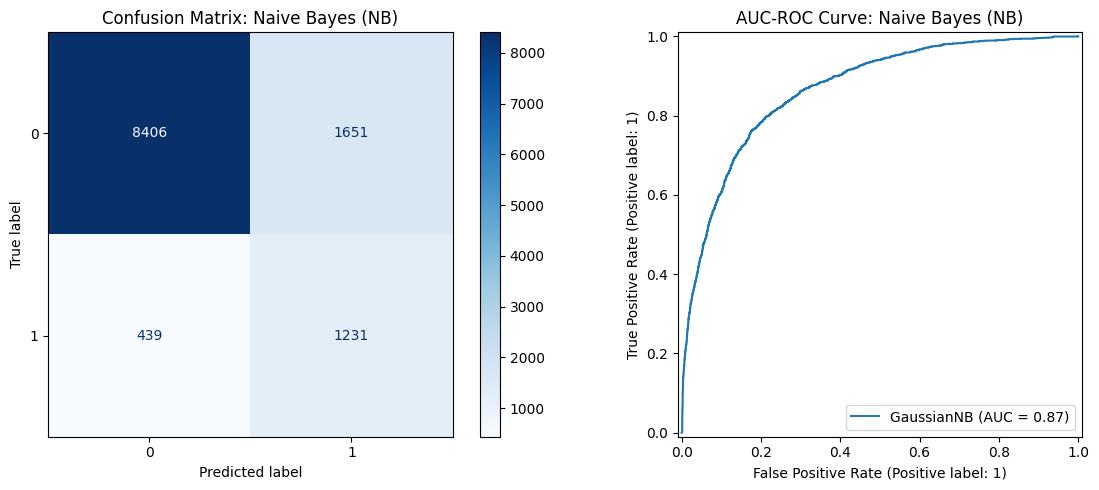

In [ ]:
# Initialize the Gaussian Naïve Bayes classifier.
nb_model = GaussianNB()

# Fit the Naïve Bayes model to the training data.
nb_model.fit(X_train, y_train)

# Evaluate the Naïve Bayes model and store its results.
nb_results = evaluate_model(nb_model, X_test, y_test, 'Naive Bayes (NB)')

## Model 2 — Logistic Regression (LR)



Model: Logistic Regression (LR)

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     10057
           1       0.73      0.42      0.53      1670

    accuracy                           0.90     11727
   macro avg       0.82      0.70      0.74     11727
weighted avg       0.88      0.90      0.88     11727



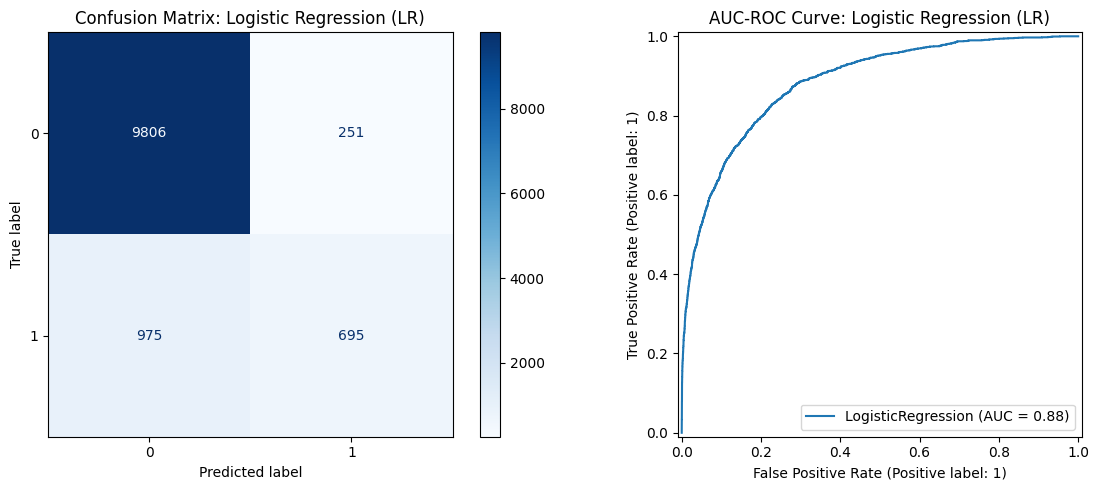

In [ ]:
# Initialize the Logistic Regression model with a high max_iter for convergence and a random_state for reproducibility.
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)

# Fit the Logistic Regression model to the training data.
lr_model.fit(X_train, y_train)

# Evaluate the Logistic Regression model and store its results.
lr_results = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression (LR)')

## Model 3 — K-Nearest Neighbours (KNN)



Model: K-Nearest Neighbours (KNN, K=5)

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95     10057
           1       0.80      0.55      0.65      1670

    accuracy                           0.92     11727
   macro avg       0.86      0.76      0.80     11727
weighted avg       0.91      0.92      0.91     11727



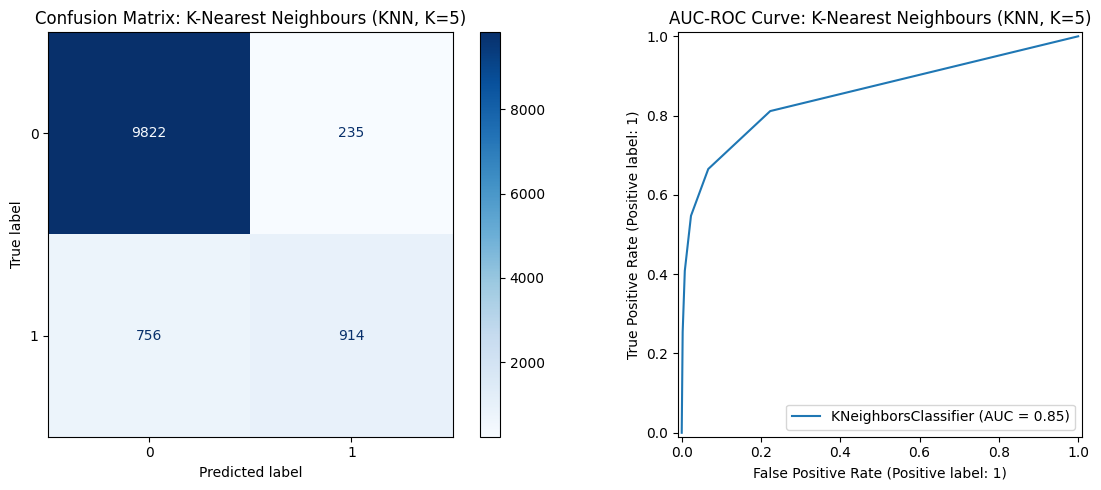

In [ ]:
# Initialize the K-Nearest Neighbours classifier with n_neighbors set to 5.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Fit the KNN model to the training data.
knn_model.fit(X_train, y_train)

# Evaluate the KNN model and store its results.
knn_results = evaluate_model(knn_model, X_test, y_test, 'K-Nearest Neighbours (KNN, K=5)')

## Summary Table of All Model Results

In [ ]:
# Compile the results from all models into a list of dictionaries and create a DataFrame.
results_df = pd.DataFrame([nb_results, lr_results, knn_results])

# Print a descriptive header for the summary table.
print('Summary of All Classification Model Test Scores:')

# Display the DataFrame, setting the 'model' column as the index for better readability.
results_df.set_index('model')

Summary of All Classification Model Test Scores:


,accuracy,precision,recall,f1,auc
model,,,,,
Naive Bayes (NB),0.821779,0.427134,0.737126,0.540861,0.867530
Logistic Regression (LR),0.895455,0.734672,0.416168,0.531346,0.883911
"K-Nearest Neighbours (KNN, K=5)",0.915494,0.795474,0.547305,0.648457,0.854866


## Hyperparameter Tuning — GridSearchCV on Best Model (Logistic Regression)

Based on analysis, Logistic Regression is selected as the best model due to its highest AUC-ROC and Recall scores. We tune its hyperparameters using GridSearchCV.

In [ ]:
# Define the parameter grid for GridSearchCV, specifying different C values, penalty types, and solvers for Logistic Regression.
param_grid = {'C': [0.01, 0.1, 1, 10],'penalty': ['l2'],'solver': ['lbfgs', 'liblinear']}

# Print the specified parameter grid to the console.
print("Specified Parameters Grid:\n", param_grid)

# Initialize GridSearchCV with Logistic Regression model, the parameter grid, 5-fold cross-validation and 'recall' as the scoring metric.
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5, scoring='recall')

# Fit GridSearchCV to the training data to find the best hyperparameters.
grid_search_lr.fit(X_train, y_train)

# Print the best hyperparameters found by GridSearchCV.
print("\nEstimated Best Hyperparameters:\n", grid_search_lr.best_params_)

Specified Parameters Grid:
 {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}

Estimated Best Hyperparameters:
 {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}



Model: Tuned Logistic Regression (LR)

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     10057
           1       0.73      0.42      0.53      1670

    accuracy                           0.90     11727
   macro avg       0.82      0.70      0.74     11727
weighted avg       0.88      0.90      0.88     11727



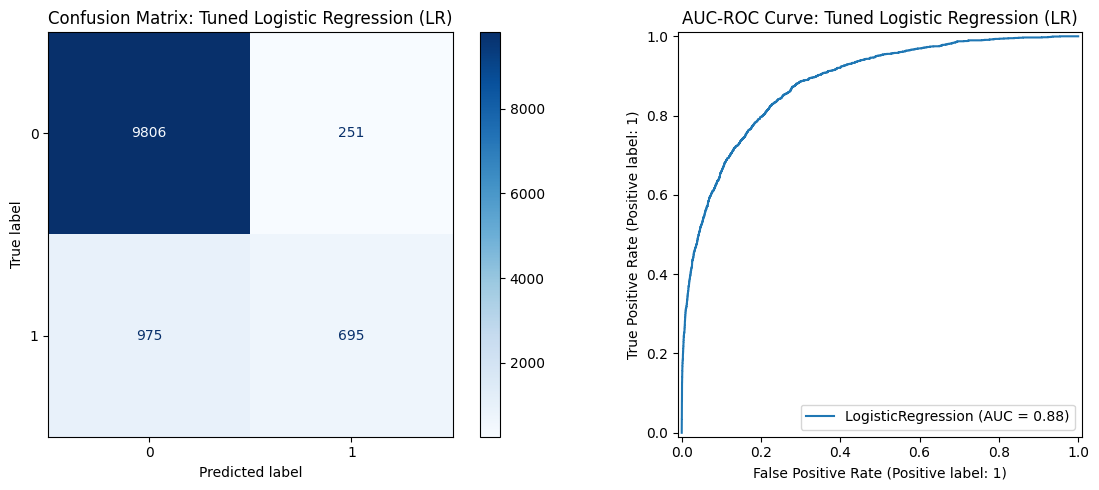


--- Comparison Before and After Tuning ---
Recall (Before Tuning): 0.4162
Recall (After Tuning):  0.4162
AUC-ROC (Before):       0.8839
AUC-ROC (After):        0.8839


In [ ]:
# Retrieve the best model from GridSearchCV
best_lr_model = grid_search_lr.best_estimator_
# Evaluate the tuned Logistic Regression model on the test set
tuned_lr_results = evaluate_model(best_lr_model, X_test, y_test, 'Tuned Logistic Regression (LR)')

# Print a header to separate comparison section
print('\n--- Comparison Before and After Tuning ---')
# Print the recall score before hyperparameter tuning, formatted to four decimal places.
print(f"Recall (Before Tuning): {lr_results['recall']:.4f}")
# Print the recall score after hyperparameter tuning, formatted to four decimal places.
print(f"Recall (After Tuning):  {tuned_lr_results['recall']:.4f}")
# Print the AUC-ROC score before hyperparameter tuning, formatted to four decimal places.
print(f"AUC-ROC (Before):       {lr_results['auc']:.4f}")
# Print the AUC-ROC score after hyperparameter tuning, formatted to four decimal places.
print(f"AUC-ROC (After):        {tuned_lr_results['auc']:.4f}")